# 1. Variables and data types

Learn to name values, distinguish common Python types, convert text deliberately, and reason about assignment and shared mutable objects. Prerequisite: [Python and Jupyter introduction](../../../00_Getting_Started/03_python_and_jupyter_introduction.ipynb). No additional programming experience is assumed. This begins the full Python sequence after the introductory route. Allow two hours, with time to predict each printed value before execution.

## 2. What problem does this solve?

A program needs to represent different kinds of information: how many readings were collected, a measured temperature, a sensor identifier, whether a check passed, and whether a reading is missing. Treating every piece of information as interchangeable leads to errors. The text `'0012'` might be an identifier that must retain its zeros, while the number 12 might be a count that can be added.

A variable name gives a value a role in a calculation. Descriptive names reduce the amount of meaning a reader must reconstruct. `temperature_c` conveys more than `a`, especially when a second value uses another temperature scale.

## 3. Intuition and analogy

Think of names as removable labels attached to objects. Assignment attaches or reattaches a label; it does not create a permanent algebraic relationship between two names. Two labels can refer to the same object. Whether changing one operation affects the other name depends on whether the object itself was modified or a name was rebound to a different object.

This label analogy is more useful than imagining every name as an independent box. It explains why assigning one list to another name does not automatically copy all its contents.

## 4. Terminology

An **int** stores an integer; a **float** stores a finite-precision numerical representation; a **str** stores text; a **bool** stores `True` or `False`. `None` is a special value commonly used to represent absence. A **literal** writes a value directly, such as `12` or `'sensor-A'`.

**Assignment** binds a name to an object. **Rebinding** changes which object the name refers to. A **mutable** object can change internally, while an **immutable** object's value cannot be changed in place. Lists are mutable; numbers and strings are immutable. **Conversion** constructs a value in another representation, and may fail if the input is unsuitable.

## 5. Mathematical foundations

Consider the conversion $F=(9/5)C+32$, where C is a Celsius reading and F the corresponding Fahrenheit reading. Multiplication changes the size of a temperature interval; adding 32 changes the zero point. These are alternative coordinates for the same temperature, not evidence that a day became hotter.

For C=20, first compute $9/5=1.8$, then $1.8\times20=36$, then add 32 to obtain 68. Both inputs and outputs are scalars. In Python, `/` returns a floating-point result, so the calculated output is typically `68.0` even if the input was the integer 20.

## 6. Hand-calculated example

A record says identifier `'007'`, temperature `'20.0'`, and reading count `'3'`, all received as text. Keep the identifier as text because leading zeros matter. Convert temperature to a float, and count to an integer. Missing temperature should remain missing rather than becoming zero, because zero Celsius is a real measurement.

The converted temperature is 20.0 and its Fahrenheit equivalent is 68.0. The count is three. The identifier remains exactly `'007'`. These choices depend on meaning, not merely whether characters look like digits.

## 7. Implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
sensor_id = '007'
raw_temperature = '20.0'
raw_count = '3'
temperature_c = float(raw_temperature)
reading_count = int(raw_count)
temperature_f = (9 / 5) * temperature_c + 32
is_available = True
missing_reading = None
print(sensor_id, temperature_c, reading_count, temperature_f)
assert sensor_id == '007' and temperature_f == 68.0
assert reading_count == 3 and missing_reading is None

007 20.0 3 68.0


## 8. Step-by-step output inspection

In [3]:
for name, value in [('identifier', sensor_id), ('temperature', temperature_c),
                    ('count', reading_count), ('available', is_available), ('missing', missing_reading)]:
    print(name, repr(value), type(value).__name__)
first = 10
second = first
first = first + 1
assert first == 11 and second == 10

identifier '007' str
temperature 20.0 float
count 3 int
available True bool
missing None NoneType


`repr` displays a diagnostic representation, including quotes around strings. The loop visits named examples; later lessons teach loops in detail. Updating `first` binds it to the result 11. It does not alter the integer ten to which `second` still refers. Printed formatting alone can hide a type distinction, so inspect types when debugging.

## 9. Library support for exact decimals

The standard library's Decimal type can represent decimal values supplied as strings exactly within its arithmetic context. This differs from binary floating-point. Use it when a domain requires specified decimal behavior; scientific arrays usually use floating-point with appropriate tolerances.

In [4]:
from decimal import Decimal
from math import isclose
binary_total = 0.1 + 0.2
decimal_total = Decimal('0.1') + Decimal('0.2')
print('Binary float:', repr(binary_total))
print('Decimal:', decimal_total)
assert isclose(binary_total, 0.3, rel_tol=0, abs_tol=1e-15)
assert decimal_total == Decimal('0.3')

Binary float: 0.30000000000000004
Decimal: 0.3


Constructing Decimal from a float can preserve that float's approximation, so the strings are deliberate. Decimal does not automatically settle currency rounding policy or validate inputs.

## 10. Visualization

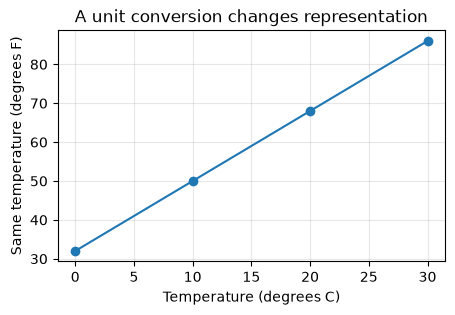

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
celsius = [0, 10, 20, 30]
fahrenheit = [(9 / 5) * value + 32 for value in celsius]
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(celsius, fahrenheit, marker='o')
ax.set(xlabel='Temperature (degrees C)', ylabel='Same temperature (degrees F)', title='A unit conversion changes representation')
ax.grid(alpha=0.3)
display(fig)
plt.close(fig)
assert fahrenheit == [32, 50, 68, 86]

The straight line records a known conversion rule. It is not a learned relationship or a comparison of two different physical temperatures. Changing representation can change a number without changing the underlying quantity.

## 11. Realistic experiment: shared data

In [6]:
readings = [20.0, 21.0]
alias = readings
alias.append(22.0)
assert readings == [20.0, 21.0, 22.0]
independent = readings.copy()
independent.append(23.0)
assert len(readings) == 3 and len(independent) == 4
print('Shared original:', readings, 'Independent copy:', independent)

Shared original: [20.0, 21.0, 22.0] Independent copy: [20.0, 21.0, 22.0, 23.0]


Both initial names refer to one list, so appending through either name changes that shared list. `.copy()` creates a separate outer list here. For lists containing nested mutable objects, a shallow copy still shares those inner objects; deeper copying requires deliberate treatment. This simple example contains immutable numbers, so the outer copy is sufficient.

## 12. Representation choices

No model parameters are learned. Choose types based on meaning and operations. Keep identifiers as text when leading zeros matter. Use Boolean values for explicit flags. Use a documented missing-value representation, and validate conversions at data boundaries. Avoid converting every column to float just because a later model expects numerical features.

## 13. Evaluation

Check both value and type when semantics require them. Test ordinary, missing, malformed, and boundary inputs. A conversion that succeeds can still be wrong: `int(3.9)` truncates toward zero rather than rounding to the nearest integer. If a count must be whole, rejecting a fractional value may be safer than silently truncating it.

## 14. Assumptions and limitations

Our text examples use a period as decimal separator and contain no unit suffix. Real records may include commas, spaces, or locale-specific formatting. Conversion must follow the documented data format. Python's flexible naming allows a name to refer to different types over time, but unnecessary type changes make programs harder to reason about.

## 15. Common mistakes and debugging

`bool('False')` is true because a nonempty string is truthy; it does not parse the word's meaning. `None` is not zero, an empty string, or a missing column. Use `is None` for the absence sentinel and `==` for value equality. Avoid shadowing built-in names such as `str` or `int`. Store units in names or schema documentation rather than relying on memory.

## 16. Comparison with alternatives

Plain Python values suit small control logic and mixed records. NumPy arrays add homogeneous numerical operations. pandas combines labeled columns with potentially different types. Data classes can later describe structured records explicitly. None of these representations removes the need to define what each field means.

## 17. Exercises

1. **Beginner:** Choose types for postal code `'01234'`, number of visits, temperature, and an active/inactive flag.
2. **Beginner:** Predict the values after `a=5; b=a; a=8`.
3. **Beginner:** Convert ten Celsius to Fahrenheit by hand.
4. **Intermediate:** Explain why `int(2.9)` is unsuitable for validating a whole-number count.
5. **Intermediate:** Demonstrate when two list names observe the same append and how to make an independent flat copy.
6. **Challenge:** Parse text flags accepting only `'true'` and `'false'`, ignoring surrounding whitespace and capitalization, and reject ambiguous values.

## 18. Detailed solutions

1. Use text for the postal code, an integer for visits, a float or domain-specific numeric type for temperature, and a Boolean for activity.
2. a refers to eight and b still refers to five; rebinding a does not rewrite b.
3. $1.8\times10+32=50$ degrees Fahrenheit.
4. The result is two, so conversion hides the invalid fraction. Check the input satisfies the count rule before accepting it.
5. Assignment shares the list; `.copy()` separates a flat list's outer container. Nested objects may still be shared.
6. Normalize the spelling, then match an explicit allowed vocabulary. Raising an error preserves evidence of unexpected input instead of inventing a flag.

In [7]:
def parse_flag(text):
    normalized = text.strip().casefold()
    if normalized == 'true':
        return True
    if normalized == 'false':
        return False
    raise ValueError('Expected true or false')

assert parse_flag(' TRUE ') is True
assert parse_flag('False') is False
try:
    parse_flag('maybe')
except ValueError:
    print('Ambiguous flag correctly rejected')
else:
    raise AssertionError('Ambiguous flag accepted')

Ambiguous flag correctly rejected


## 19. Knowledge check

**Is a numeric-looking string a number?** No; its type and meaning remain text until converted. **What does assignment copy?** A reference is bound; a deep object copy is not implied. **Is zero missing?** Not unless the domain explicitly defines it that way. **Why inspect type?** Similar printed values can behave differently. **Why use descriptive names?** They preserve the role and units of data.

## 20. Interview preparation

**Mutable versus immutable?** Whether an object's internal value can change in place. **Equality versus identity?** Equal values versus the same object. **Why not test floats only with exact equality?** Finite representation can introduce tiny rounding differences. **Why preserve identifier text?** Leading zeros and formatting may carry meaning. **How validate external data?** Apply documented schema and domain constraints before conversion and computation.

## 21. Summary and next steps

Names, values, types, and units jointly determine a program's meaning. Continue to [Operators](../../../01_Python_Foundations/02_operators.ipynb), where you will combine those values without confusing arithmetic, comparison, and logical decisions.